# Load Dataset

In [1]:
!pip install transformers[torch]
!pip install datasets
!pip install accelerate
!pip install evaluate
!pip install bert-score
!pip install sacrebleu
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 18.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.1 MB/s eta 0:00:00
    

In [2]:
import torch
import transformers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sentencepiece
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from nltk.util import ngrams
from wordcloud import WordCloud
from torch.utils.data import Dataset, DataLoader
from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import load_dataset
from sacrebleu.metrics import BLEU, CHRF, TER
from bert_score import score as bert_score
from nltk.translate.meteor_score import meteor_score

from datasets import Dataset as DatasetHF
from transformers import AdamW, get_linear_schedule_with_warmup
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

In [3]:
nusax_mt = load_dataset("indonlp/NusaX-MT")
nusax_jav_ind = load_dataset("indonlp/NusaX-MT", name='ind-jav')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.64k [00:00<?, ?B/s]

NusaX-MT.py:   0%|          | 0.00/5.69k [00:00<?, ?B/s]

The repository for indonlp/NusaX-MT contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/indonlp/NusaX-MT.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

## Train

In [4]:
df_train = nusax_jav_ind['train'].to_pandas()
df_train.head()

,id,text_1,text_2,text_1_lang,text_2_lang
0,0,Nikmati cicilan 0% hingga 12 bulan untuk pemes...,Nikmatono cicilan 0% sampek 12 sasi dinggo pes...,ind,jav
1,1,Kue-kue yang disajikan bikin saya bernostalgia...,Roti-roti sing disajekne nggarai aku nostalgia...,ind,jav
2,2,Ibu pernah bekerja di grab indonesia,Ibu uwis tahu kerja ing grab indonesia,ind,jav
3,3,Paling suka banget makan siang di sini ayam sa...,Paling seneng banget mangan awan ing kene pith...,ind,jav
4,4,Pelayanan bus DAMRI sangat baik,Pelayanane bis DAMRI apik banget.,ind,jav


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           500 non-null    object
 1   text_1       500 non-null    object
 2   text_2       500 non-null    object
 3   text_1_lang  500 non-null    object
 4   text_2_lang  500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB


## Test

In [6]:
df_test = nusax_jav_ind['test'].to_pandas()
df_test.head()

,id,text_1,text_2,text_1_lang,text_2_lang
0,0,"Dekat dengan hotel saya menginap, hanya ditemp...","Cepak saka hotelku nginep, namung digawa mlaku...",ind,jav
1,1,"Iya benar, dia sedang jaga warung.","Iya bener, deknen lagi jaga warung.",ind,jav
2,2,Kangkungnya lumayan tapi kepiting saus padangn...,Kangkunge lumayan nanging yuyu saus padange ng...,ind,jav
3,3,Bertempat di braga city walk yang satu gedung ...,Manggon nang braga city walk sing sak gedung k...,ind,jav
4,4,Gianyar terima bantuan sosial 2018 sebesar rp ...,Gianyar nompo bantuan sosial 2018 gedene rp 44...,ind,jav


In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           400 non-null    object
 1   text_1       400 non-null    object
 2   text_2       400 non-null    object
 3   text_1_lang  400 non-null    object
 4   text_2_lang  400 non-null    object
dtypes: object(5)
memory usage: 15.8+ KB


## Validation

In [8]:
df_valid = nusax_jav_ind['validation'].to_pandas()
df_valid.head()

,id,text_1,text_2,text_1_lang,text_2_lang
0,0,Jika ada pertanyaan lebih lanjut yang ingin ka...,Lak ana pitakonan sakteruse sing sir mok eruhi...,ind,jav
1,1,Rasanya sih kok harga kaki lima dan rasanya ya...,"Rasane kok rega kaki lima, lan rasane yo ora b...",ind,jav
2,2,"Minimal cek pesan saya, ada problem yang rumit...","Minimal cek pesenku, ana masalah sing ruwet, n...",ind,jav
3,3,Dulu restoran ini merupakan favorit saya karen...,Mbien restoran iki yaiku favoritku amarga rega...,ind,jav
4,4,Merupakan resto vintage dengan harga yang cuku...,Iku uga resto vintage sek regane cukup terjang...,ind,jav


In [9]:
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           100 non-null    object
 1   text_1       100 non-null    object
 2   text_2       100 non-null    object
 3   text_1_lang  100 non-null    object
 4   text_2_lang  100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


# Prepocessing

In [10]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [11]:
stopwords_df = pd.read_csv('stopword.csv')
stopwords_dict = {
    'ind': set(stopwords_df['indonesian'].dropna().tolist()),
    'jav': set(stopwords_df['javanese'].dropna().tolist()),
    'sun': set(stopwords_df['sundanese'].dropna().tolist())
}

def clean_content(content, lang):
    # Mengkonversi teks menjadi huruf kecil
    content = content.lower()

    # Menghapus tanda baca dan angka
    content = re.sub(r'[^a-z\s]', '', content)

    # Mengganti karakter yang berulang-ulang (contoh: sooo -> so)
    content = re.sub(r'(.)\1{2,}', r'\1\1', content)

    # Tokenisasi
    words = content.split()

    # Remove stopword sesuai bahasa
    words = [word for word in words if word not in stopwords_dict.get(lang, set())]

    # Menggabungkan kata-kata menjadi satu string
    cleaned_content = ' '.join(words)

    return cleaned_content


In [12]:
df_list = [df_train, df_test, df_valid]

for i, df in enumerate(df_list):
    df[f'text_1_cleaned'] = df.apply(lambda row: clean_content(row['text_1'], row['text_1_lang']), axis=1)
    df[f'text_2_cleaned'] = df.apply(lambda row: clean_content(row['text_2'], row['text_2_lang']), axis=1)

In [13]:
df_train[['text_1_cleaned','text_2_cleaned']]

,text_1_cleaned,text_2_cleaned
0,nikmati cicilan pemesanan tiket pesawat air as...,nikmatono cicilan sampek sasi dinggo pesen tik...
1,kuekue disajikan bikin bernostalgia tipikal ku...,rotiroti sing disajekne nggarai nostalgianan m...
2,grab indonesia,uwis tahu kerja grab indonesia
3,suka banget makan siang ayam sambalnya enak ba...,seneng mangan awan kene pithik sambele enak re...
4,pelayanan bus damri,pelayanane bis damri
...,...,...
495,si a omongnya tong kosong nyaring bunyinya bic...,si omonge tong kosong banter unine enek bobote
496,sambalnya terasinya khas asin manisnya pas rua...,sambele liya terasine khas tenan asin legine p...
497,steaknya enak pesan gede aja empuk sebarkan fo...,miturutku stike enak luwah pesen sing gede wae...
498,dijaga ya makannya gus emang musimnya iyasi je...,dijaga ya mangane gus pancen lagi musime iya s...


# EDA

In [14]:
df = pd.concat([df_train, df_test, df_valid], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1000 non-null   object
 1   text_1          1000 non-null   object
 2   text_2          1000 non-null   object
 3   text_1_lang     1000 non-null   object
 4   text_2_lang     1000 non-null   object
 5   text_1_cleaned  1000 non-null   object
 6   text_2_cleaned  1000 non-null   object
dtypes: object(7)
memory usage: 54.8+ KB


## Wordclound

In [15]:
def plot_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(" ".join(text))
    plt.figure(figsize = (10, 8), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(title)
    plt.show()

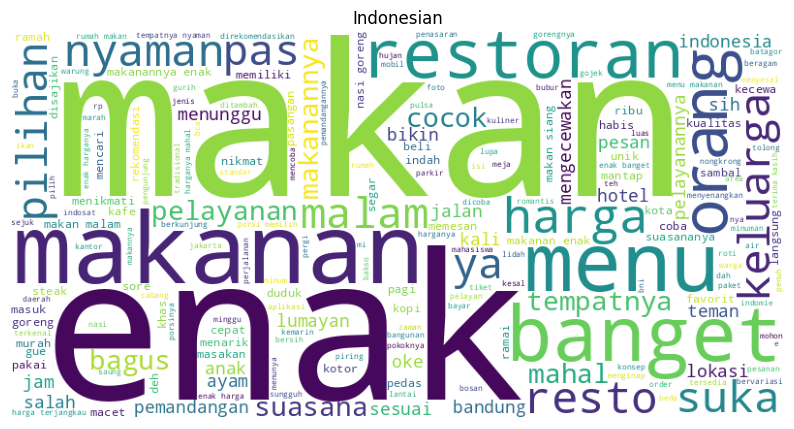

In [16]:
plot_word_cloud(df['text_1_cleaned'], 'Indonesian')

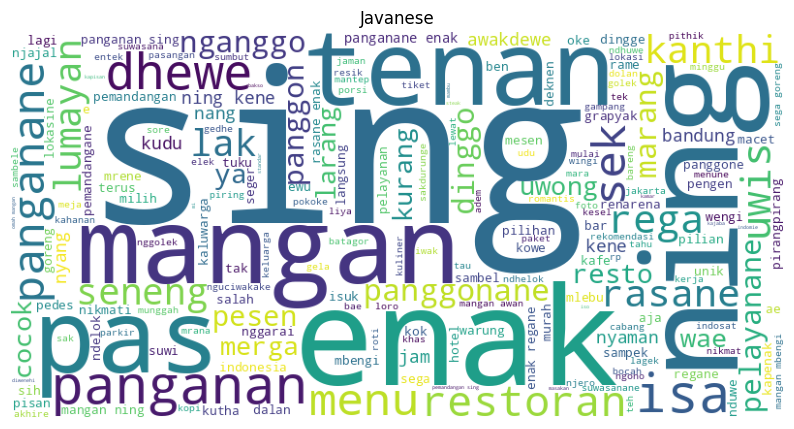

In [17]:
plot_word_cloud(df['text_2_cleaned'], 'Javanese')

## Top 10 Words

In [18]:
def bar_plot(text, title):
    word_counts = Counter(" ".join(text).split())
    top_words = word_counts.most_common(10)
    words, counts = zip(*top_words)
    plt.figure(figsize=(10, 6))
    plt.bar(words, counts)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

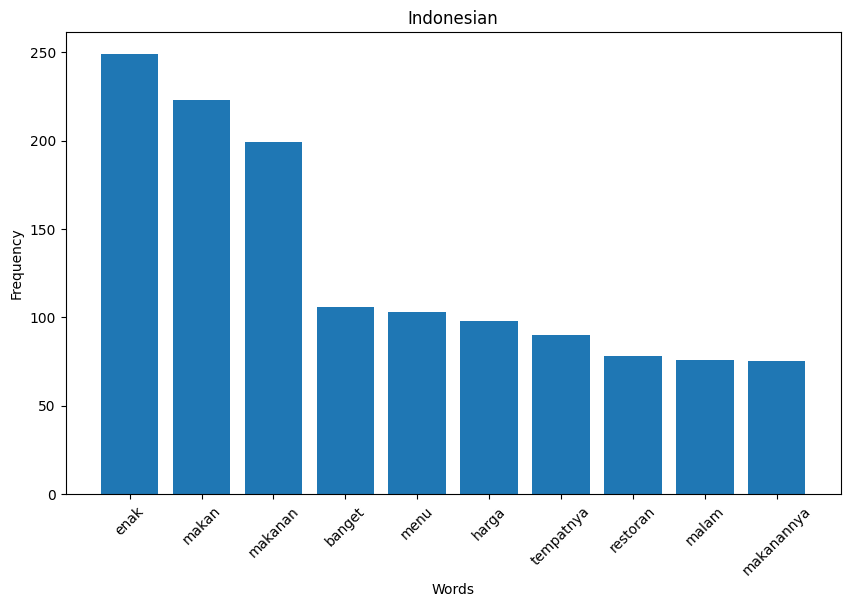

In [19]:
bar_plot(df['text_1_cleaned'], 'Indonesian')

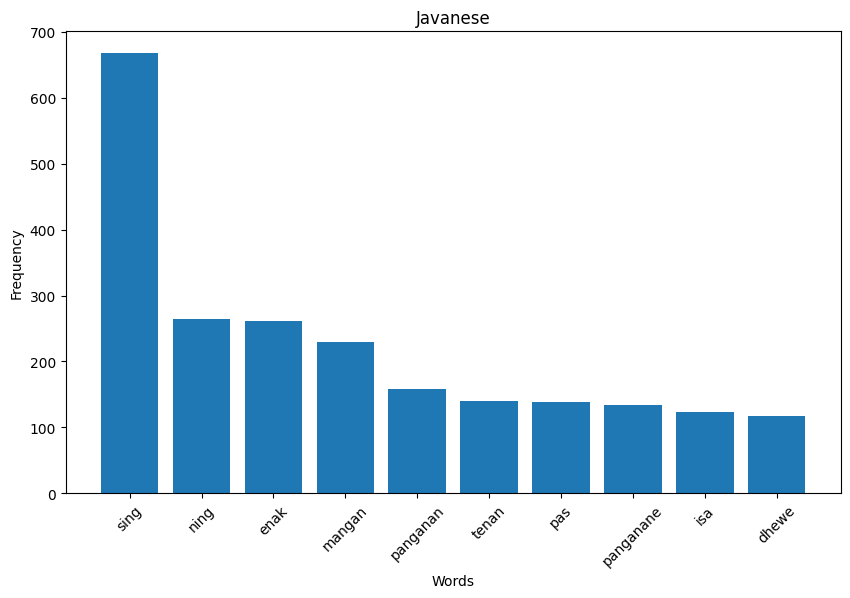

In [20]:
bar_plot(df['text_2_cleaned'], 'Javanese')

# Splitting

In [21]:
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42, shuffle=True)

print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Test data size: {len(test_data)}")

Train data size: 800
Validation data size: 100
Test data size: 100


# Modelling

In [22]:
import evaluate

sacrebleu_metric = evaluate.load("sacrebleu")
meteor_metric = evaluate.load("meteor")
bertscore_metric = evaluate.load("bertscore")

# Fungsi untuk post-processing teks prediksi dan label
def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [[label.strip()] for label in labels]
    return preds, labels

# Fungsi untuk menghitung metrik evaluasi
def compute_metrics(preds, labels):
    preds, labels = postprocess_text(preds, labels)

    # Initialize result dictionary
    result = {}

    # Compute sacreBLEU
    bleu_result = sacrebleu_metric.compute(predictions=preds, references=labels)
    result["bleu"] = bleu_result["score"]

    # Compute METEOR
    meteor_result = meteor_metric.compute(predictions=preds, references=labels)
    result["meteor"] = meteor_result["meteor"]

    # Compute BERTScore
    bertscore_result = bertscore_metric.compute(
        predictions=preds, references=labels, lang="id"  # Indonesia ke Jawa
    )
    result["bertscore_precision"] = np.mean(bertscore_result["precision"])
    result["bertscore_recall"] = np.mean(bertscore_result["recall"])
    result["bertscore_f1"] = np.mean(bertscore_result["f1"])

    # Round metrics for readability
    result = {k: round(v, 4) for k, v in result.items()}
    return result

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [23]:
! pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.8 MB/s eta 0:00:00


In [24]:
from deep_translator import GoogleTranslator

# Fungsi untuk terjemahan menggunakan Deep Translator
def translate_texts_deep(texts, src_lang="id", dest_lang="jw"):
    translations = []
    for text in texts:
        try:
            translation = GoogleTranslator(source=src_lang, target=dest_lang).translate(text)
            translations.append(translation)
        except Exception as e:
            translations.append("")  # Jika ada error, tambahkan teks kosong
            print(f"Error during translation: {e}")
    return translations

source_texts = test_data['text_1_cleaned'].tolist()

test_data['predicted_translation'] = translate_texts_deep(source_texts, src_lang="id", dest_lang="jw")

In [25]:
test_data[['text_1_cleaned', 'text_2_cleaned','predicted_translation']].head()

,text_1_cleaned,text_2_cleaned,predicted_translation
436,bosan kali kenal ayam goreng suharti langsung ...,tau bose tahun kapisan kenal pithik goreng suh...,Bosen langsung kenal ayam goreng Suharti Top m...
899,menunggu makanannya banget waitressnya galak p...,panganan suwi pelayane galak pas mangan pas pe...,Ngenteni panganan pancen greget nalika pangana...
346,warga jakarta malu kang oknum bertanggung swee...,warga jakarta isin mas oknum sek ndhuwe tanggu...,Warga Jakarta isin karo sing tanggung jawab ny...
60,bakso favorit sekeluarga gurih super enak dite...,bakso favorite dhewe sakaluwarga rasane gurih ...,"Bola bakar sing paling disenengi kulawarga, Su..."
867,bubur ahong enak dimakan makan malam menu dini...,bubur ahong enak dipangan pas mangan wengi men...,Bubur ahong enak dipangan nalika nedha bengi


In [27]:
test_data.to_csv('google_translate.csv', index=False)

In [28]:
preds = test_data['predicted_translation'].tolist()
labels = test_data['text_2_cleaned'].tolist()
metrics = compute_metrics(preds, labels)

print(metrics)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

{'bleu': 3.1494, 'meteor': 0.2712, 'bertscore_precision': 0.7421, 'bertscore_recall': 0.7198, 'bertscore_f1': 0.7305}


## Translation

In [29]:
source_text = "Saya makan ayam goreng di rumah tadi malam."

translated_text = GoogleTranslator(source='id', target='jw').translate(source_text)

# Print hasil
print("Source:", source_text)
print("Translation:", translated_text)

Source: Saya makan ayam goreng di rumah tadi malam.
Translation: Aku wingi bengi mangan ayam goreng ning omah.
